### Segment Anything 2.1 – Point-based, box-based, and automatic mask generation methods for Faba bean images

#### This notebook is adapted from the official SAM2 repository: https://github.com/facebookresearch/sam2. For SAM2, Copyright (c) Meta Platforms, Inc. and affiliates. All rights reserved. (Licensed under the Apache License, Version 2.0 (the "License"). 

#### Original Research Publication: Ravi N, Gabeur V, Hu YT, Hu R, Ryali C, Ma T, Khedr H, Rädle R, Rolland C, Gustafson L, Mintun E, Pan J, Alwala KV, Carion N, Wu CY, Girshick R, Dollár P, Feichtenhofer C. SAM 2: segment anything in images and videos. arXiv. 2024;arXiv:2408.00714. doi.org/10.48550/arXiv.2408.00714.

#### Adapted from:
#### - https://github.com/facebookresearch/sam2/blob/main/sam2/automatic_mask_generator.py
#### - https://github.com/facebookresearch/sam2/blob/main/notebooks/image_predictor_example.ipynb

#### Modifications: image loading/rotation, box-prompt coordinates, batch prompt coordinates,
#### mask post-processing, and figure generation were adapted for faba bean seed image segmentation and
#### phenotyping. Core SAM2 model-loading and prediction logic is used largely unmodified from the original notebook.

In [1]:
using_colab = True
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam2.git'

    !mkdir -p images
    !wget -P images https://raw.githubusercontent.com/facebookresearch/sam2/main/notebooks/images/cars.jpg

    !mkdir -p ../checkpoints/
    !wget -P ../checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA is available: True
  Cloning https://github.com/facebookresearch/sam2.git to /tmp/pip-req-build-qa323eue
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/sam2.git /tmp/pip-req-build-qa323eue
  Resolved https://github.com/facebookresearch/sam2.git to commit 2b90b9f5ceec907a1c18123530e92e794ad901a4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
--2026-08-18 14:41:45--  https://raw.githubusercontent.com/facebookresearch/sam2/main/notebooks/images/cars.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1058188 (1.0M) [image/jpeg]
Saving to: ‘images/cars.jpg.3’

cars

In [2]:
#Import the required libraries
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

import cv2
import pandas as pd
import seaborn as sns
import os as os
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")

In [3]:
np.random.seed(3)

def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='yellow', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='yellow', facecolor=(0, 0, 0, 0), lw=2))

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure()
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=10)
            plt.axis('off')
            plt.savefig(f"predictoronimage{i+1}.jpg", format='jpg', dpi=300)
        plt.axis('off')
        plt.show()

def show_masks2(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure()
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=10)
            plt.axis('off')
            plt.savefig(f"predictoronimage_on{i+1}.jpg", format='jpg', dpi=300)
        plt.axis('on')
        plt.show()

def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

For experimentation, image Vf1-1-2 has been used.

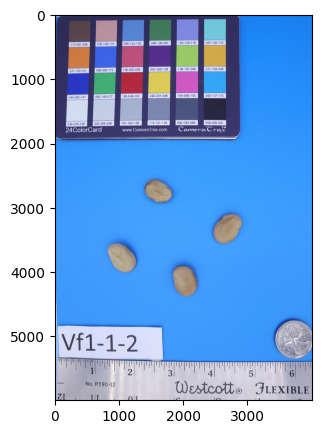

In [4]:
import cv2
from pathlib import Path
image_path = "/content/sample_data/Faba-Seed-CC_Vf1-1-2.JPG"
image=cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(image)
ax.axis('on')

# Save BEFORE show
fig.savefig(
    "plotted_image.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Predictor based SAM 2.1:

This code imports two key components from the sam2 library:

build_sam2: This function is responsible for initializing and building the SAM2 (Segment Anything Model v2) model.

SAM2ImagePredictor: This class is responsible for processing images and generating segmentation masks.

model_cfg: This variable stores the path to a YAML configuration file (sam2.1_hiera_l.yaml), which defines various hyperparameters and settings for the model.

sam2_checkpoint: This variable stores the path to a pre-trained checkpoint file (sam2.1_hiera_large.pt). This checkpoint contains the learned weights of the model, which allow it to make predictions without requiring retraining.

device: Runs the model on the CPU

build_sam2 function: loads the model architecture, configures the model parameters based on sam2.1_hiera_l.yaml, loads the pre-trained weights from sam2.1_hiera_large.pt

SAM2ImagePredictor instance: for processing images and generating segmentation masks.The predictor is initialized with the sam2_model created earlier.

set_image(image) function: preprocesses the image (resizing, normalizing, converting to tensors, etc.), prepares it for segmentation, stores it in memory so the model can generate masks based on it.


In [5]:
#import the required libraries
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

#specify the model configs and checkpoints
sam2_checkpoint = "../checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"
device = "cuda"
# use sam predictor for generating masks
sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device) #initialises the SAM2.1 model
predictor = SAM2ImagePredictor(sam2_model)
predictor.set_image(image)

#### Point based SAM2.1

Points are input to the model in (x,y) format and come with labels 1 (foreground point) or 0 (background point).The single input point is ambiguous, and the model has returned multiple objects consistent with it.

In [6]:
# input x,y points and label number for detecting that particular seed
input_point = np.array([[1600, 2700]])
input_label = np.array([1])


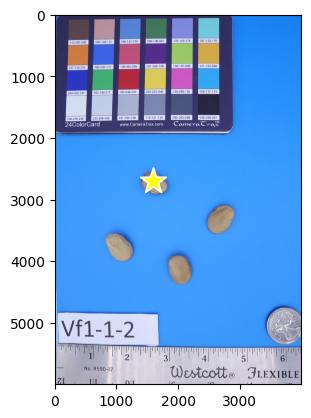

In [7]:
# visualize the point on the image for a particular seed
plt.figure()
plt.imshow(image)
show_points(input_point, input_label, plt.gca())
plt.axis('on')
plt.show()

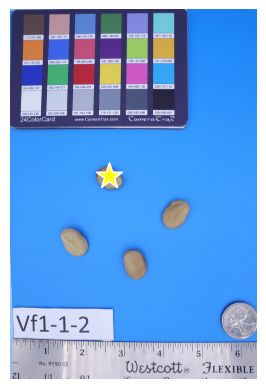

In [8]:
# visualize the point on the image for a particular seed
plt.figure()
plt.imshow(image)
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.savefig(f"pointonimage_off.jpg", format='jpg', dpi=600)
plt.show()

In [9]:
print(predictor._features["image_embed"].shape, predictor._features["image_embed"][-1].shape)

torch.Size([1, 256, 64, 64]) torch.Size([256, 64, 64])


In [10]:
# generate the masks
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)
sorted_ind = np.argsort(scores)[::-1]
masks = masks[sorted_ind]
scores = scores[sorted_ind]
logits = logits[sorted_ind]

In [11]:
masks.shape

(3, 6000, 4000)

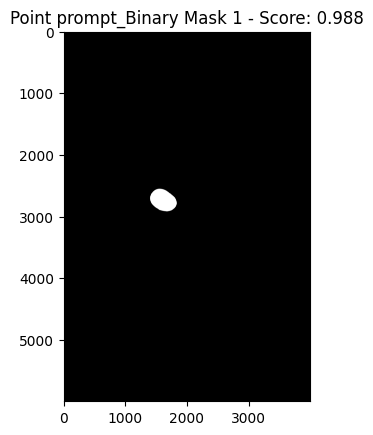

Saved binary mask 1: Pointprompt_binary_mask_1.png


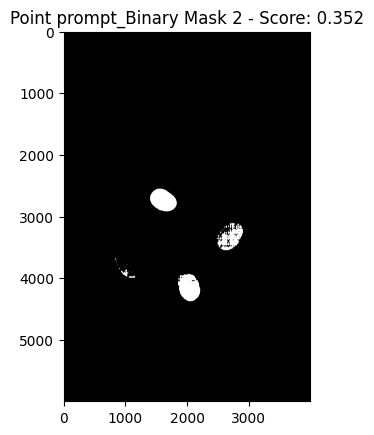

Saved binary mask 2: Pointprompt_binary_mask_2.png


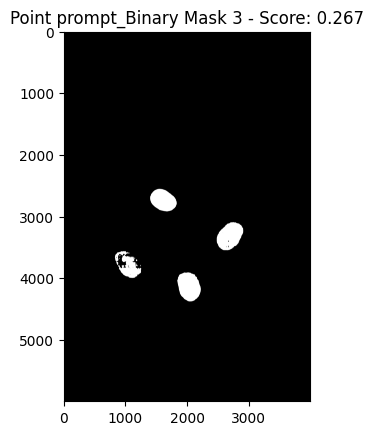

Saved binary mask 3: Pointprompt_binary_mask_3.png


In [12]:
for i, mask in enumerate(masks, start=1):

    # Convert mask to binary:
    # background = 0 (black)
    # object     = 255 (white)
    binary_mask = (mask > 0).astype(np.uint8) * 255

    # Create figure
    fig, ax = plt.subplots()

    # Plot binary mask
    ax.imshow(binary_mask, cmap='gray', vmin=0, vmax=255)

    ax.set_title(
        f"Point prompt_Binary Mask {i} - Score: {scores[i-1]:.3f}",
        fontsize=12
    )

    ax.axis('on')

    # Save plotted binary mask as PNG
    fig.savefig(
        f"Pointprompt_binary_mask_{i}.png",
        format='png',
        dpi=600,
        bbox_inches='tight',
        pad_inches=0
    )

    plt.show()
    plt.close(fig)

    print(f"Saved binary mask {i}: Pointprompt_binary_mask_{i}.png")

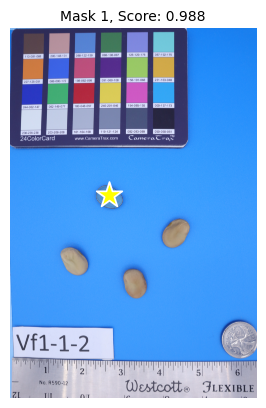

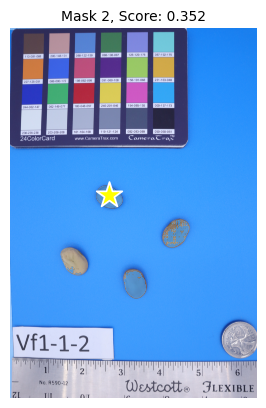

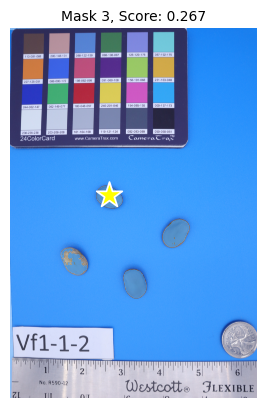

In [13]:
show_masks(image, masks, scores, point_coords=input_point, input_labels=input_label, borders=True)

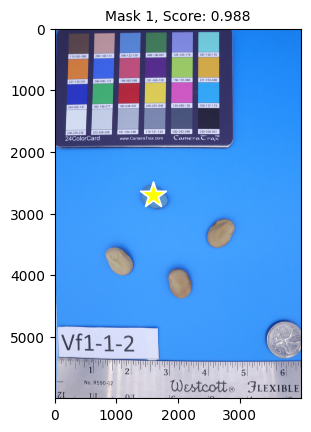

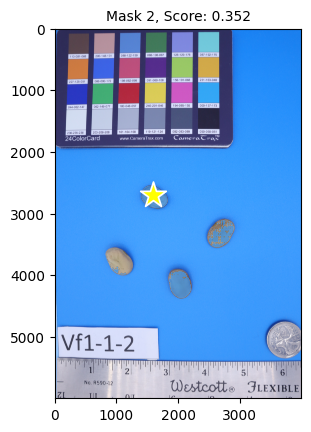

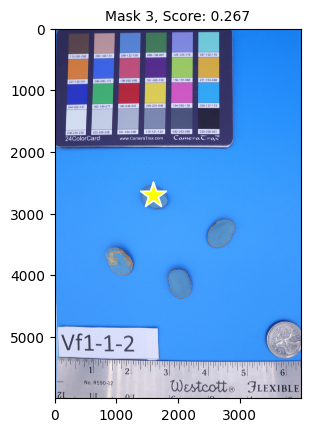

In [14]:
show_masks2(image, masks, scores, point_coords=input_point, input_labels=input_label, borders=True)

#### Box-based SAM2.1
Box based prompt:
The model can also take a box as input, provided in xyxy format (diagonally opposite x1y1 and x2y2).


In [15]:
# rectangular box coordinates for a seed[x1,y1,x2,y2]
input_box = np.array([1300,2400,1900,3000])


In [16]:
masks, scores, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=input_box[None, :],
    multimask_output=True,
)
sorted_ind = np.argsort(scores)[::-1]
masks = masks[sorted_ind]
scores = scores[sorted_ind]


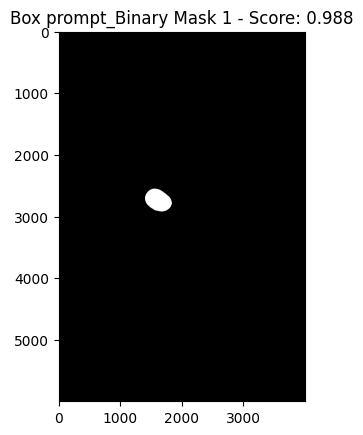

Saved binary mask 1: Boxprompt_binary_mask_1.png


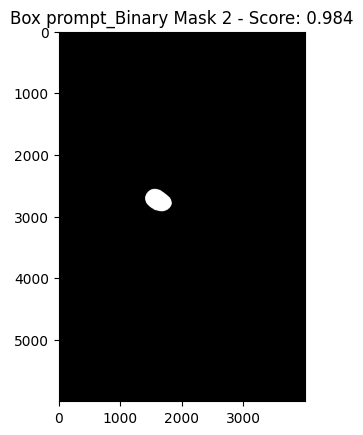

Saved binary mask 2: Boxprompt_binary_mask_2.png


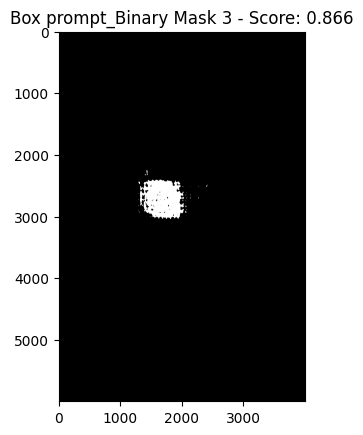

Saved binary mask 3: Boxprompt_binary_mask_3.png


In [17]:
for i, mask in enumerate(masks, start=1):

    # Convert mask to binary:
    # background = 0 (black)
    # object     = 255 (white)
    binary_mask = (mask > 0).astype(np.uint8) * 255

    # Create figure
    fig, ax = plt.subplots()

    # Plot binary mask
    ax.imshow(binary_mask, cmap='gray', vmin=0, vmax=255)

    ax.set_title(
        f"Box prompt_Binary Mask {i} - Score: {scores[i-1]:.3f}",
        fontsize=12
    )

    ax.axis('on')

    # Save plotted binary mask as PNG
    fig.savefig(
        f"Boxprompt_binary_mask_{i}.png",
        format='png',
        dpi=600,
        bbox_inches='tight',
        pad_inches=0
    )

    plt.show()
    plt.close(fig)

    print(f"Saved binary mask {i}: Boxprompt_binary_mask_{i}.png")

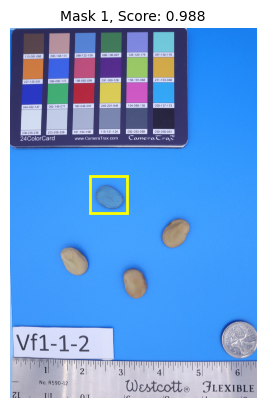

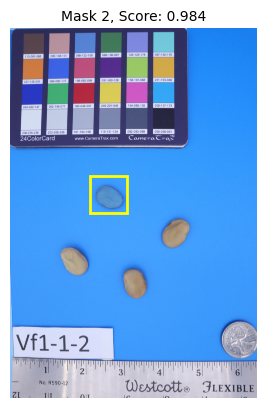

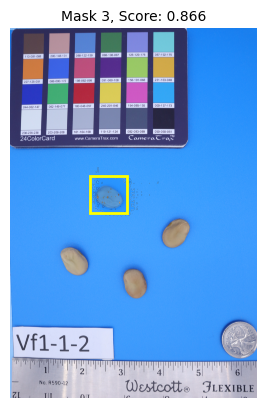

In [18]:
show_masks(image, masks, scores, box_coords=input_box)

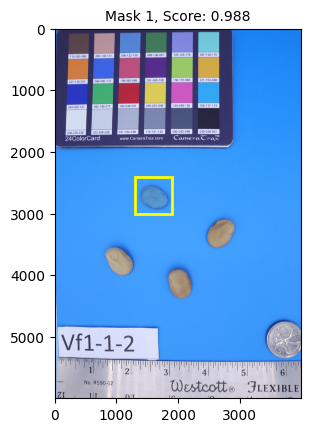

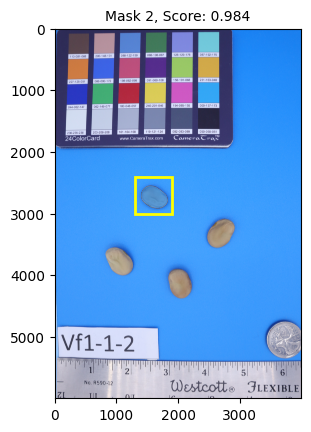

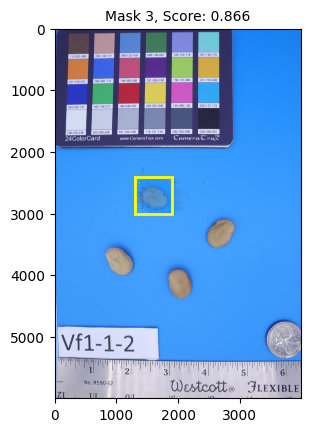

In [19]:
show_masks2(image, masks, scores, box_coords=input_box)

#### Batched Input points
SamPredictor can take multiple input prompts for the same image, using predictor.predict method. This method assumes input points are already torch tensors and have already been transformed to the input frame.

In [20]:
input_boxes = np.array([[1300,2400,1900,3000],
 [2300,3000, 3000, 3700],
 [1700, 3800, 2300, 4500],
  [700, 3400, 1500, 4200],])

masks, scores, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=input_boxes,
    multimask_output=False,
)
masks.shape  # (batch_size) x (num_predicted_masks_per_input) x H x W


(4, 1, 6000, 4000)

In [21]:
masks, scores, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=input_boxes,
    multimask_output=False,
)

In [22]:

masks.shape  # (batch_size) x (num_predicted_masks_per_input) x H x W

(4, 1, 6000, 4000)

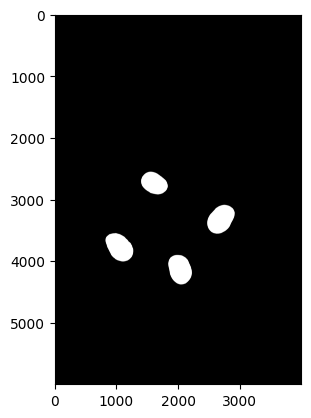

In [23]:
# masks shape: (N, 1, H, W) -> N = number of boxes/objects
# collapse the box dimension and the "num_masks_per_input" dimension (=1 since multimask_output=False)
# using logical OR: a pixel is foreground if ANY object's mask covers it
combined_mask = np.any(masks.astype(bool), axis=(0, 1))   # shape (H, W), dtype bool

# convert to a standard 8-bit black/white image: 255 = object, 0 = background
combined_mask_img = (combined_mask.astype(np.uint8)) * 255

plt.figure()
plt.imshow(combined_mask_img, cmap='gray')
plt.axis('on')
plt.savefig(f"batch_combinedmask.jpg", format='jpg', dpi=300)
plt.show()





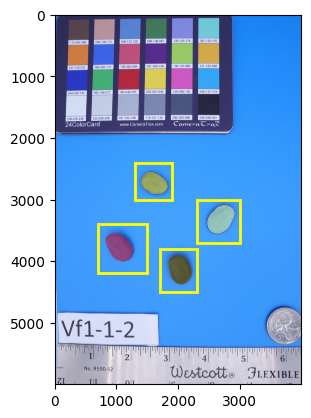

In [24]:

plt.figure()
plt.imshow(image)
for mask in masks:
    show_mask(mask.squeeze(0), plt.gca(), random_color=True)
for box in input_boxes:
    show_box(box, plt.gca())
plt.axis('on')

plt.savefig('batch_image.png', dpi=300, bbox_inches='tight')
plt.show()

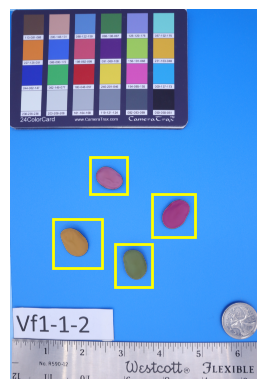

In [25]:

plt.figure()
plt.imshow(image)
for mask in masks:
    show_mask(mask.squeeze(0), plt.gca(), random_color=True)
for box in input_boxes:
    show_box(box, plt.gca())
plt.axis('off')

plt.savefig('batch_image_off.png', dpi=300, bbox_inches='tight')
plt.show()